Sentiment moyen par année (Petit échantillon) :
published_at
2006   -0.211475
2007   -0.087939
2008    0.018743
2009    0.084125
Name: sentiment_score, dtype: float64


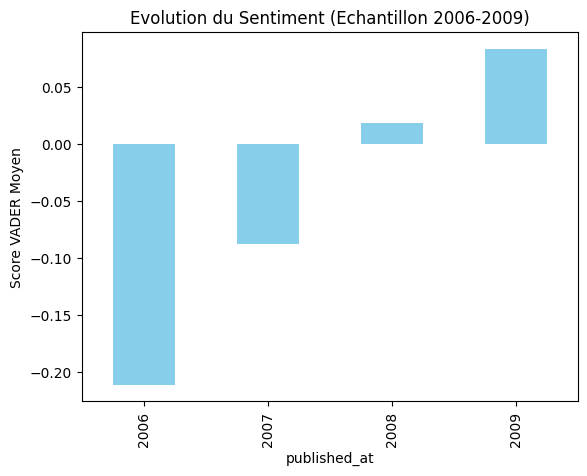

Fusion réussie. Le fichier final 'master_data_v1.csv' est prêt.
Chargement des fichiers...
Calcul des scores VADER...
Fichier master_data_v1.csv créé avec la colonne sentiment_score !


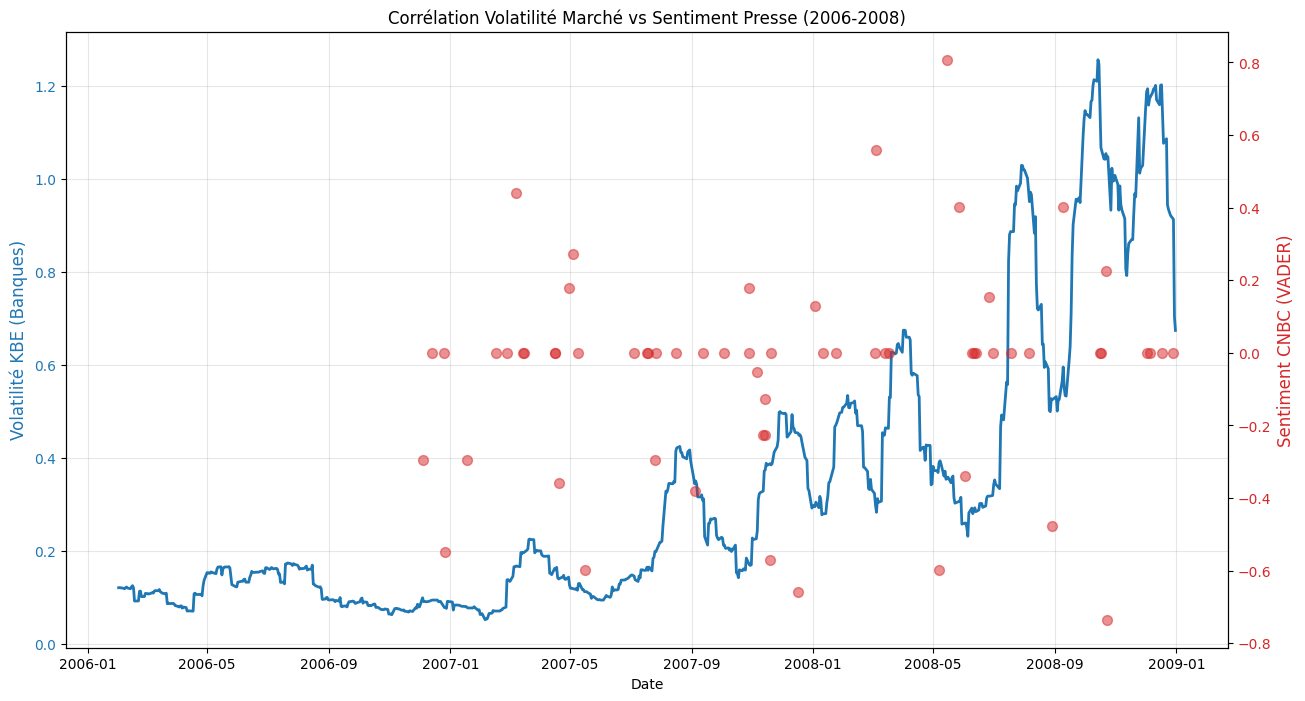

In [6]:
import pandas as pd
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt

# 1. Chargement
df = pd.read_csv('../data/cnbc_news_datase.csv')

# 2. Conversion propre des dates (Gestion du format UTC)
df['published_at'] = pd.to_datetime(df['published_at'], utc=True, errors='coerce')
df = df.dropna(subset=['published_at'])

# 3. Filtrage période de crise (2006-2009)
df_crisis = df[(df['published_at'].dt.year >= 2006) & (df['published_at'].dt.year <= 2009)].copy()

# 4. Analyse de Sentiment
sia = SentimentIntensityAnalyzer()
df_crisis['sentiment_score'] = df_crisis['title'].apply(lambda x: sia.polarity_scores(str(x))['compound'])

# 5. Moyenne par année pour voir la tendance
yearly_sentiment = df_crisis.groupby(df_crisis['published_at'].dt.year)['sentiment_score'].mean()

print("Sentiment moyen par année (Petit échantillon) :")
print(yearly_sentiment)

# 6. Petit graphique de contrôle
yearly_sentiment.plot(kind='bar', color='skyblue')
plt.title('Evolution du Sentiment (Echantillon 2006-2009)')
plt.ylabel('Score VADER Moyen')
plt.show()

import pandas as pd


df_sentiment = pd.read_csv('../data/cnbc_news_datase.csv') # fichier avec VADER
df_finance = pd.read_csv('../data/financial_data_KBE.csv')

df_sentiment['published_at'] = pd.to_datetime(df_sentiment['published_at'], utc=True).dt.date
df_finance['Date'] = pd.to_datetime(df_finance['Date'], utc=True).dt.date

df_final = pd.merge(df_finance, df_sentiment, left_on='Date', right_on='published_at', how='left')

df_final.to_csv('../data/master_data_v1.csv', index=False)
print("Fusion réussie. Le fichier final 'master_data_v1.csv' est prêt.")


import pandas as pd
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
import numpy as np

# 1. Charger les deux bases de données
print("Chargement des fichiers...")
df_news = pd.read_csv('../data/cnbc_news_datase.csv')
df_finance = pd.read_csv('../data/financial_data_KBE.csv')

# 2. CALCULER LE SENTIMENT (Le maillon qui manquait)
print("Calcul des scores VADER...")
sia = SentimentIntensityAnalyzer()
df_news['sentiment_score'] = df_news['title'].apply(lambda x: sia.polarity_scores(str(x))['compound'])

# 3. Préparer les dates pour la fusion
# On s'assure que les deux colonnes sont au format "Date" simple (YYYY-MM-DD)
df_news['Date_Merge'] = pd.to_datetime(df_news['published_at'], utc=True).dt.date
df_finance['Date_Merge'] = pd.to_datetime(df_finance['Date'], utc=True).dt.date

# 4. Fusionner les données (Merge)
# On prend la finance et on y ajoute le sentiment quand il existe
df_master = pd.merge(df_finance, df_news[['Date_Merge', 'sentiment_score', 'title']], 
                     on='Date_Merge', how='left')

# 5. Sauvegarder la version finale avec les scores
df_master.to_csv('../data/master_data_v1.csv', index=False)
print("Fichier master_data_v1.csv créé avec la colonne sentiment_score !")

# 6. VISUALISATION FINALE
fig, ax1 = plt.subplots(figsize=(15, 8))

# Axe 1 : Volatilité (Bleu)
color_vol = 'tab:blue'
ax1.set_xlabel('Date')
ax1.set_ylabel('Volatilité KBE (Banques)', color=color_vol, fontsize=12)
ax1.plot(pd.to_datetime(df_master['Date_Merge']), df_master['Volatility'], color=color_vol, lw=2)
ax1.tick_params(axis='y', labelcolor=color_vol)
ax1.grid(True, alpha=0.3)

# Axe 2 : Sentiment (Rouge)
ax2 = ax1.twinx()
color_sent = 'tab:red'
ax2.set_ylabel('Sentiment CNBC (VADER)', color=color_sent, fontsize=12)
ax2.scatter(pd.to_datetime(df_master['Date_Merge']), df_master['sentiment_score'], 
            color=color_sent, alpha=0.5, s=50, label='Sentiment des articles')
ax2.tick_params(axis='y', labelcolor=color_sent)

plt.title('Corrélation Volatilité Marché vs Sentiment Presse (2006-2008)')
plt.show()